In [110]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [111]:
# Load dataset
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
df = pd.read_csv(url, parse_dates=['Month'], index_col='Month')
df.head(10)

,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
1949-06-01,135
1949-07-01,148
1949-08-01,148
1949-09-01,136


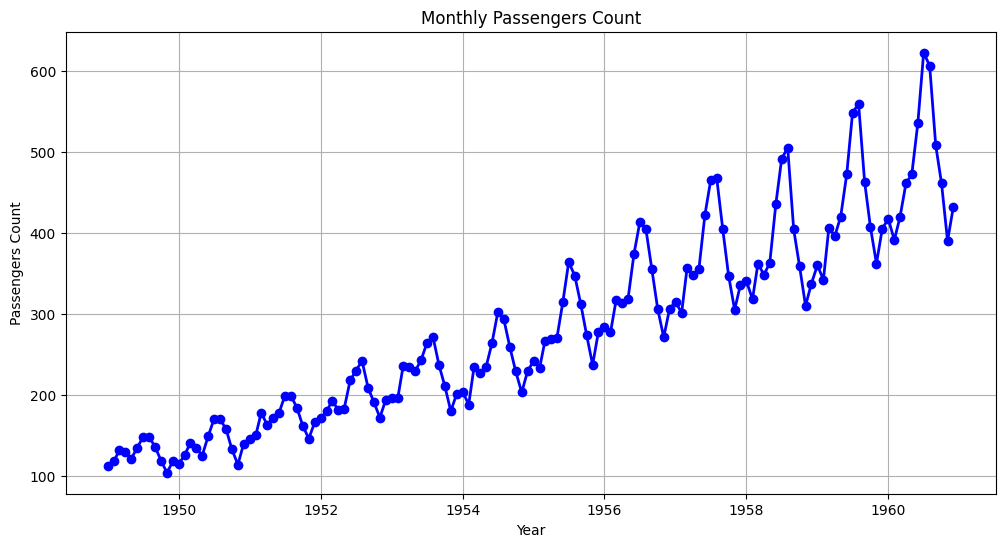

In [112]:
# Creating a line plot
plt.figure(figsize=(12, 6))
plt.plot(df, color='blue', marker='o', linestyle='-', linewidth=2, markersize=6)
plt.title('Monthly Passengers Count')
plt.xlabel('Year')
plt.ylabel('Passengers Count')
plt.grid(True)
plt.show()


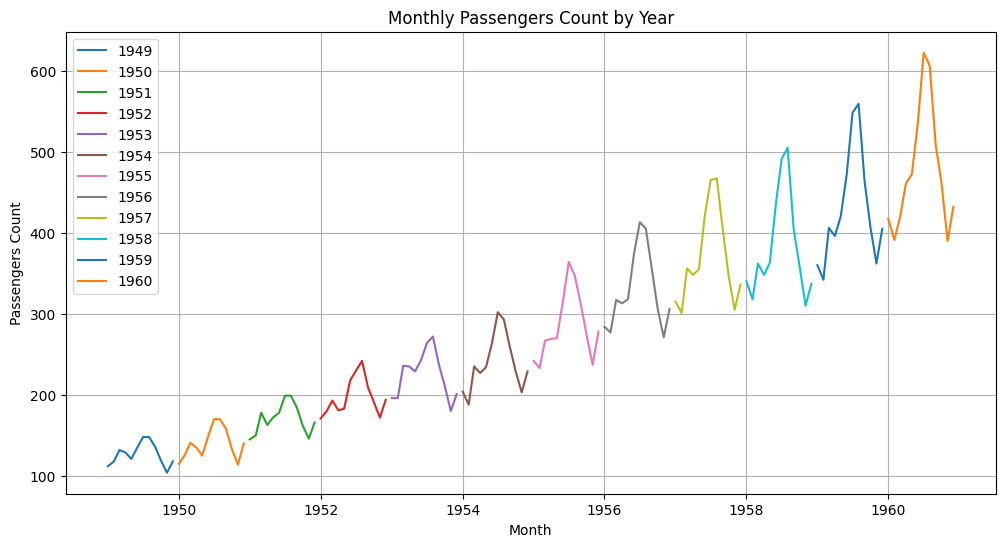

In [113]:
# Extract from data
years = df.index.year.unique()

# Plotting each year as its own line
plt.figure(figsize=(12, 6))
for year in years: 
    year_data = df[df.index.year == year]
    plt.plot(year_data['Passengers'], label=year)

plt.title('Monthly Passengers Count by Year')
plt.xlabel('Month')
plt.ylabel('Passengers Count')
plt.legend()
plt.grid(True)
plt.show()


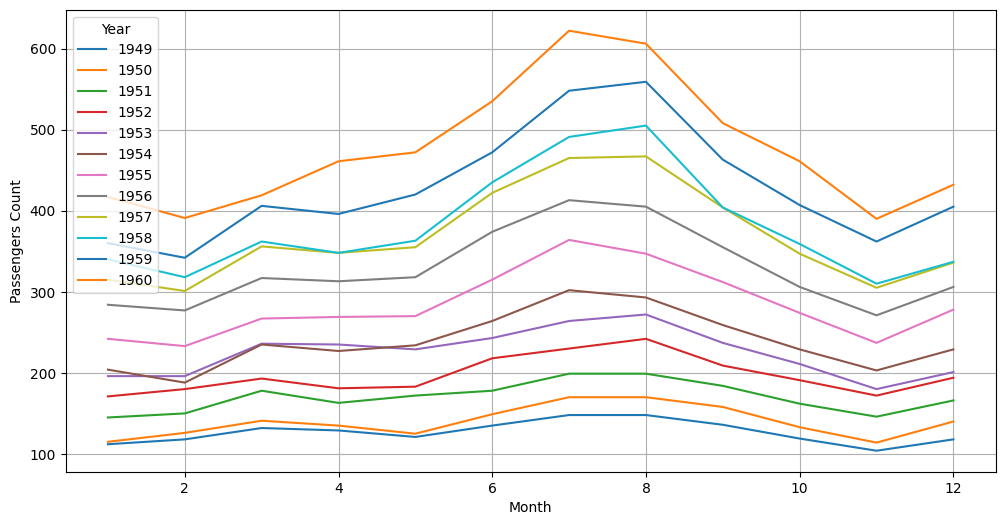

In [114]:
# Plot seasonal subseries

df['Year'] = df.index.year
df['month'] = df.index.month

# Pivot table 
table = pd.pivot_table(df, 
                       values='Passengers', 
                       index=['month'], 
                       columns='Year', 
                       aggfunc='sum')


# plot the series
fig, ax = plt.subplots(figsize=(12, 6))
table.plot(ax=ax, kind='line', legend=True)
ax.set_xlabel('Month')
ax.set_ylabel('Passengers Count')
plt.grid(True)
plt.show()


C:\Users\kakop\AppData\Local\Temp\ipykernel_19796\281454530.py:13: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df['Passengers'], shade=True)


Text(0.5, 0, 'Passengers Count')

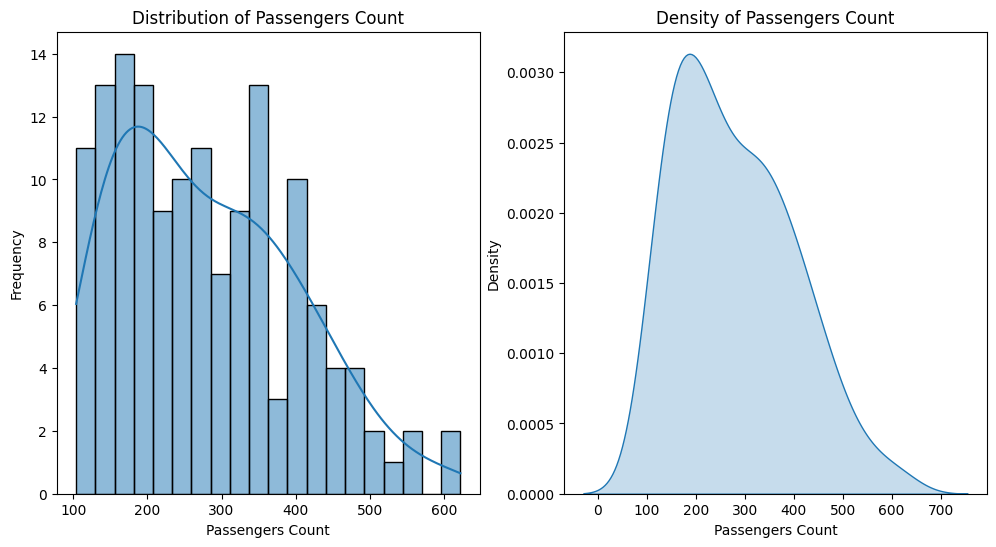

In [115]:
import seaborn as sns

# histogram
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.histplot(df['Passengers'], bins=20, kde=True)
plt.title('Distribution of Passengers Count')
plt.xlabel('Passengers Count')
plt.ylabel('Frequency')

# Density
plt.subplot(1, 2, 2)
sns.kdeplot(df['Passengers'], shade=True)
plt.title('Density of Passengers Count')
plt.xlabel('Passengers Count')

Exercise 1.

use the sunspots dataset(https:www.kaggle.com/datasetss/robertvalt/sunspots) to demonstrate basic concepts of time series

In [116]:
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("robervalt/sunspots")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\kakop\.cache\kagglehub\datasets\robervalt\sunspots\versions\3


In [117]:
csv_path = os.path.join(path, "Sunspots.csv")
df = pd.read_csv(csv_path)
df["Date"] = pd.to_datetime(df["Date"])
df.set_index("Date", inplace=True)
df= df.drop(columns=["Unnamed: 0"]) 
# Optional: rename columns for simplicity
df.rename(columns={"Monthly Mean Total Sunspot Number": "Sunspots"}, inplace=True)

# Display first few rows
print(df.head())

            Sunspots
Date                
1749-01-31      96.7
1749-02-28     104.3
1749-03-31     116.7
1749-04-30      92.8
1749-05-31     141.7


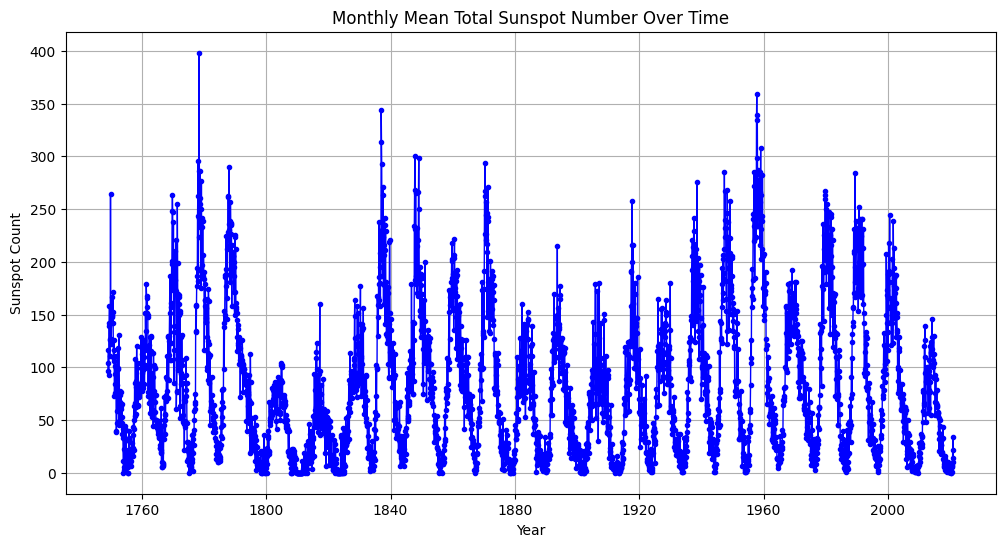

In [118]:
plt.figure(figsize=(12, 6))
plt.plot(df, color='blue', marker='o', linestyle='-', linewidth=1, markersize=3)
plt.title('Monthly Mean Total Sunspot Number Over Time')
plt.xlabel('Year')
plt.ylabel('Sunspot Count')
plt.grid(True)
plt.show()

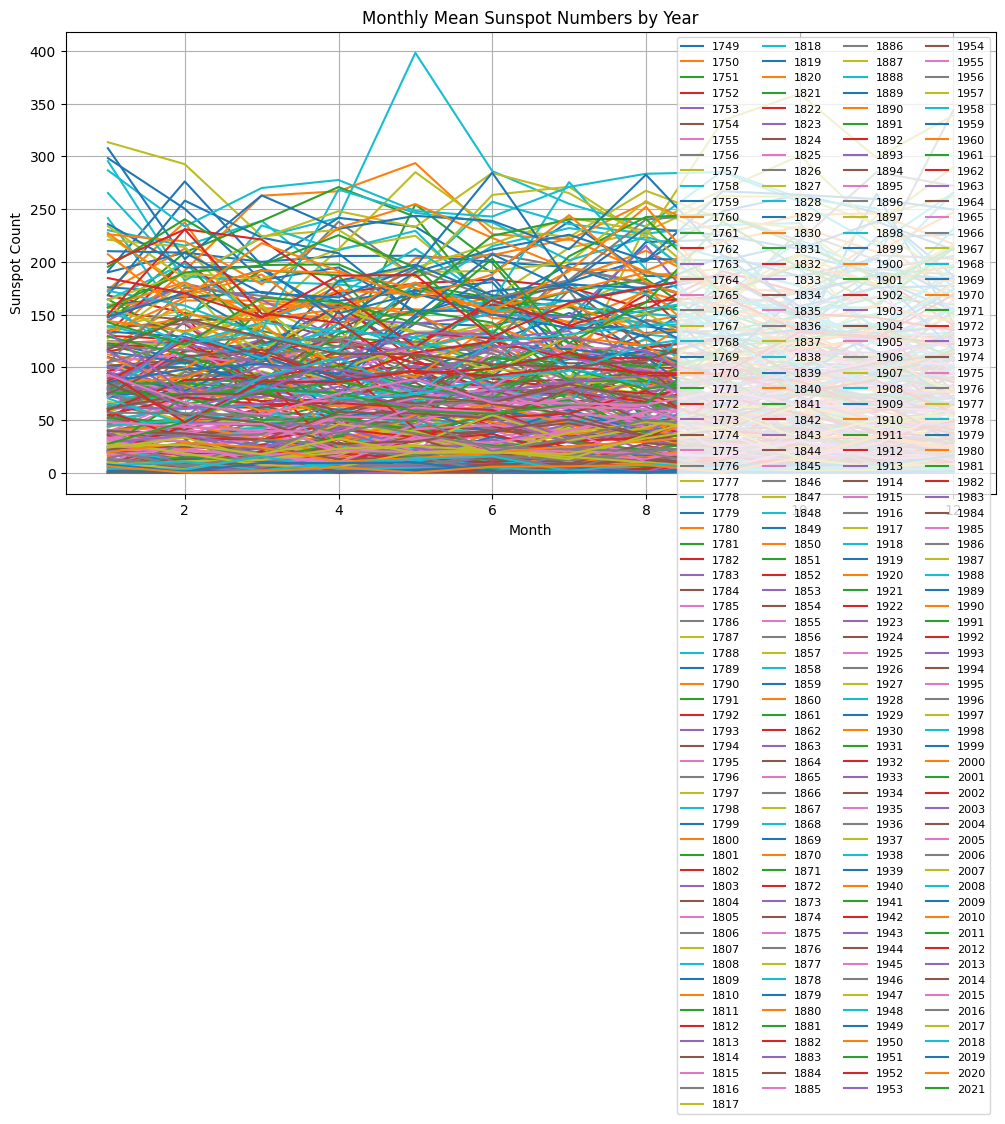

In [119]:
import matplotlib.pyplot as plt
years = df.index.year.unique()

# Plot each year's line
plt.figure(figsize=(12, 6))
for year in years:
    year_data = df[df.index.year == year]
    plt.plot(
        year_data.index.month,
        year_data['Sunspots'],
        label=year
    )

plt.title('Monthly Mean Sunspot Numbers by Year')
plt.xlabel('Month')
plt.ylabel('Sunspot Count')
plt.legend(ncol=4, fontsize=8)
plt.grid(True)
plt.show()


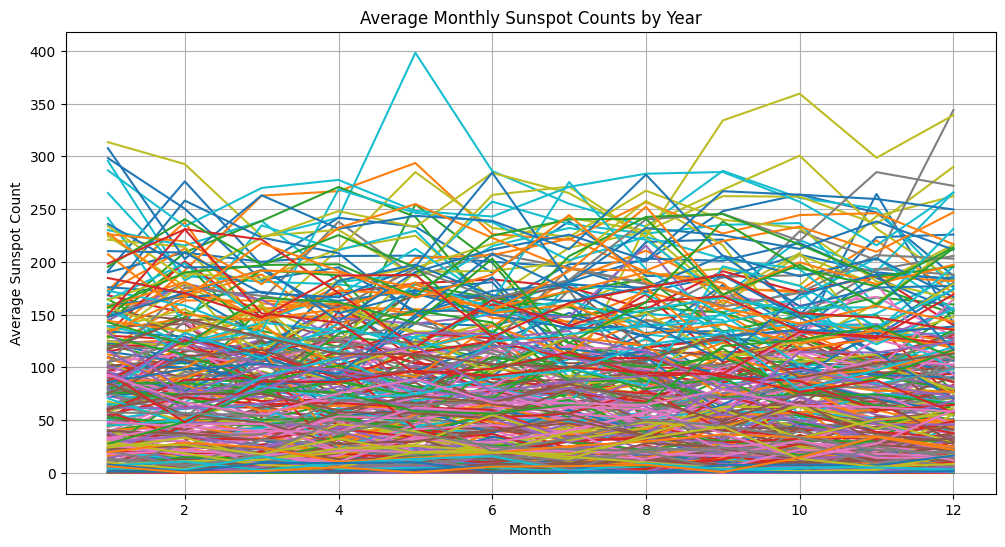

In [120]:
import pandas as pd
import matplotlib.pyplot as plt

# Make sure df index is DateTime
df.index = pd.to_datetime(df.index)
df['Month'] = df.index.month
df['Year'] = df.index.year

table = pd.pivot_table(df,
                       values='Sunspots',
                       index='Month',
                       columns='Year',
                       aggfunc='mean')

# Plot the pivoted table
fig, ax = plt.subplots(figsize=(12, 6))
table.plot(ax=ax, kind='line', legend=False)

ax.set_xlabel('Month')
ax.set_ylabel('Average Sunspot Count')
ax.set_title('Average Monthly Sunspot Counts by Year')
plt.grid(True)
plt.show()


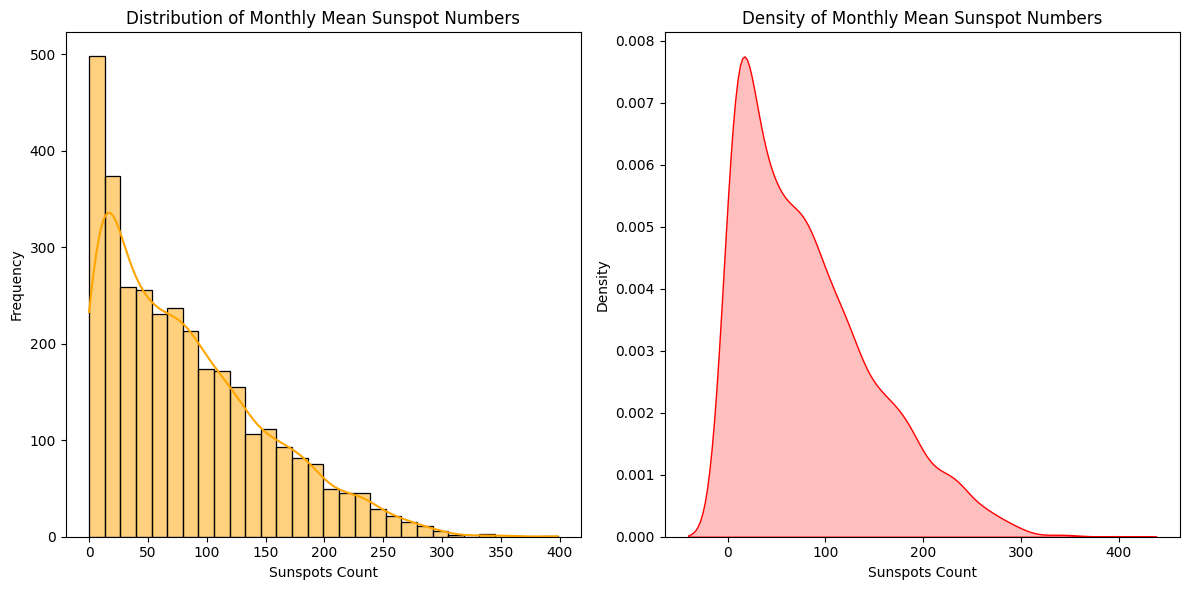

In [121]:
import seaborn as sns
# --- Distribution plots ---
plt.figure(figsize=(12, 6))
# Histogram
plt.subplot(1, 2, 1)
sns.histplot(df['Sunspots'], bins=30, kde=True, color='orange')
plt.title('Distribution of Monthly Mean Sunspot Numbers')
plt.xlabel('Sunspots Count')
plt.ylabel('Frequency')

# Density plot
plt.subplot(1, 2, 2)
sns.kdeplot(df['Sunspots'], fill=True, color='red')
plt.title('Density of Monthly Mean Sunspot Numbers')
plt.xlabel('Sunspots Count')

plt.tight_layout()
plt.show()

Exercise 2. 
Use the Unemployment in America dataset (https://kaggle.com/datasets/justin2028/unemployment-in-america-per-us-state)

In [122]:
path = kagglehub.dataset_download("justin2028/unemployment-in-america-per-us-state")
print("Path to dataset files:", path)

Path to dataset files: C:\Users\kakop\.cache\kagglehub\datasets\justin2028\unemployment-in-america-per-us-state\versions\3


In [123]:
csv_path = os.path.join(path, "Unemployment In America Per Us State.csv")
df = pd.read_csv(csv_path)
df["Date"] = pd.to_datetime(df['Year'].astype(str) + '-' + df['Month'].astype(str))
df.set_index("Date", inplace=True)
col = 'Percent (%) of Labor Force Unemployed in State/Area'

state = 'California' 
state_df = df[df['State/Area'] == state]
print(df.head())

            FIPS Code  State/Area  Year  Month  \
Date                                             
1976-01-01          1     Alabama  1976      1   
1976-01-01          2      Alaska  1976      1   
1976-01-01          4     Arizona  1976      1   
1976-01-01          5    Arkansas  1976      1   
1976-01-01          6  California  1976      1   

           Total Civilian Non-Institutional Population in State/Area  \
Date                                                                   
1976-01-01                                       2,605,000             
1976-01-01                                         232,000             
1976-01-01                                       1,621,000             
1976-01-01                                       1,536,000             
1976-01-01                                      15,621,000             

           Total Civilian Labor Force in State/Area  \
Date                                                  
1976-01-01                        

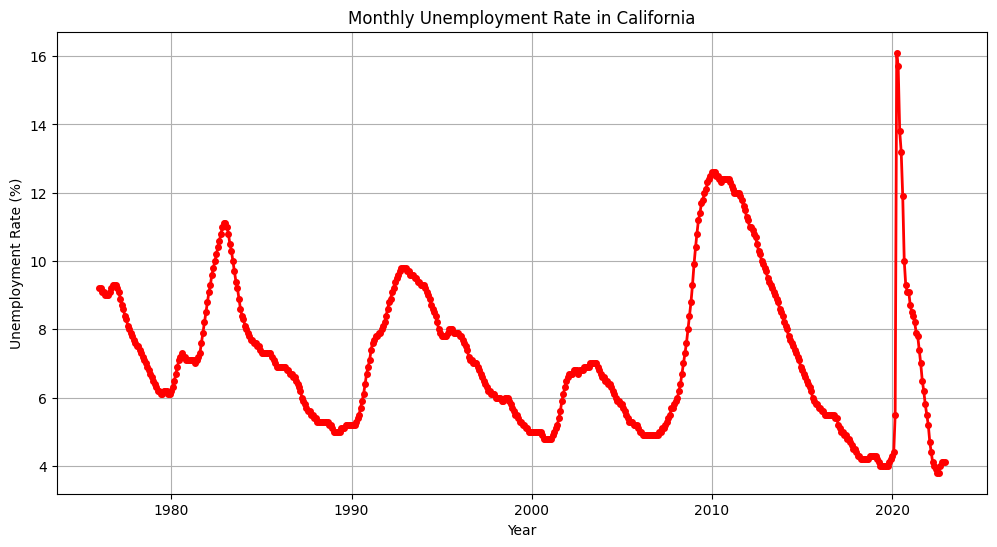

In [124]:
plt.figure(figsize=(12, 6))
plt.plot(state_df.index, state_df[col], color='red', marker='o', linestyle='-', linewidth=2, markersize=4)
plt.title(f'Monthly Unemployment Rate in {state}')
plt.xlabel('Year')
plt.ylabel('Unemployment Rate (%)')
plt.grid(True)
plt.show()

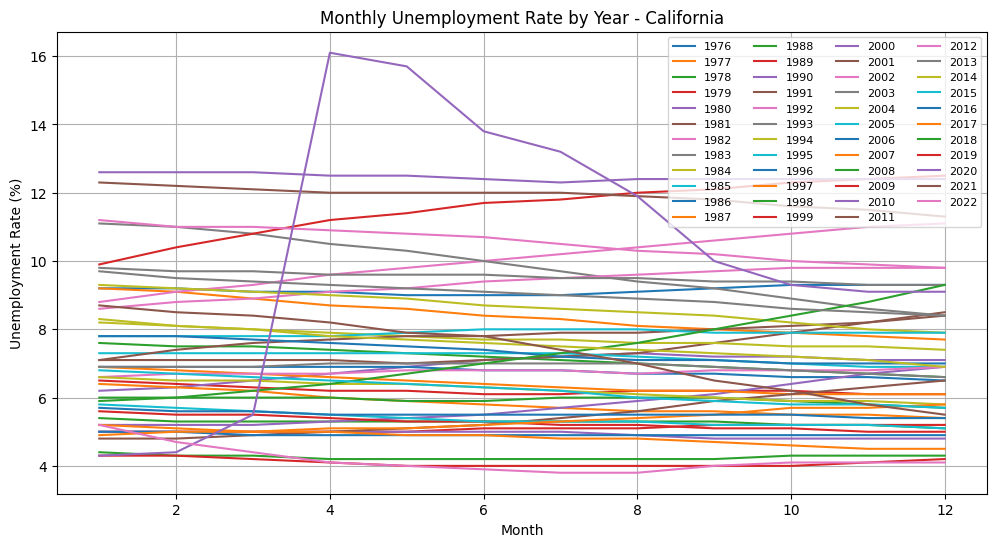

In [125]:
years = state_df.index.year.unique()

plt.figure(figsize=(12, 6))
for year in years:
    year_data = state_df[state_df.index.year == year]
    plt.plot(year_data.index.month, year_data[col], label=year)

plt.title(f'Monthly Unemployment Rate by Year - {state}')
plt.xlabel('Month')
plt.ylabel('Unemployment Rate (%)')
plt.legend(ncol=4, fontsize=8)
plt.grid(True)
plt.show()


C:\Users\kakop\AppData\Local\Temp\ipykernel_19796\3307623577.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  state_df['Year'] = state_df.index.year
C:\Users\kakop\AppData\Local\Temp\ipykernel_19796\3307623577.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  state_df['Month'] = state_df.index.month


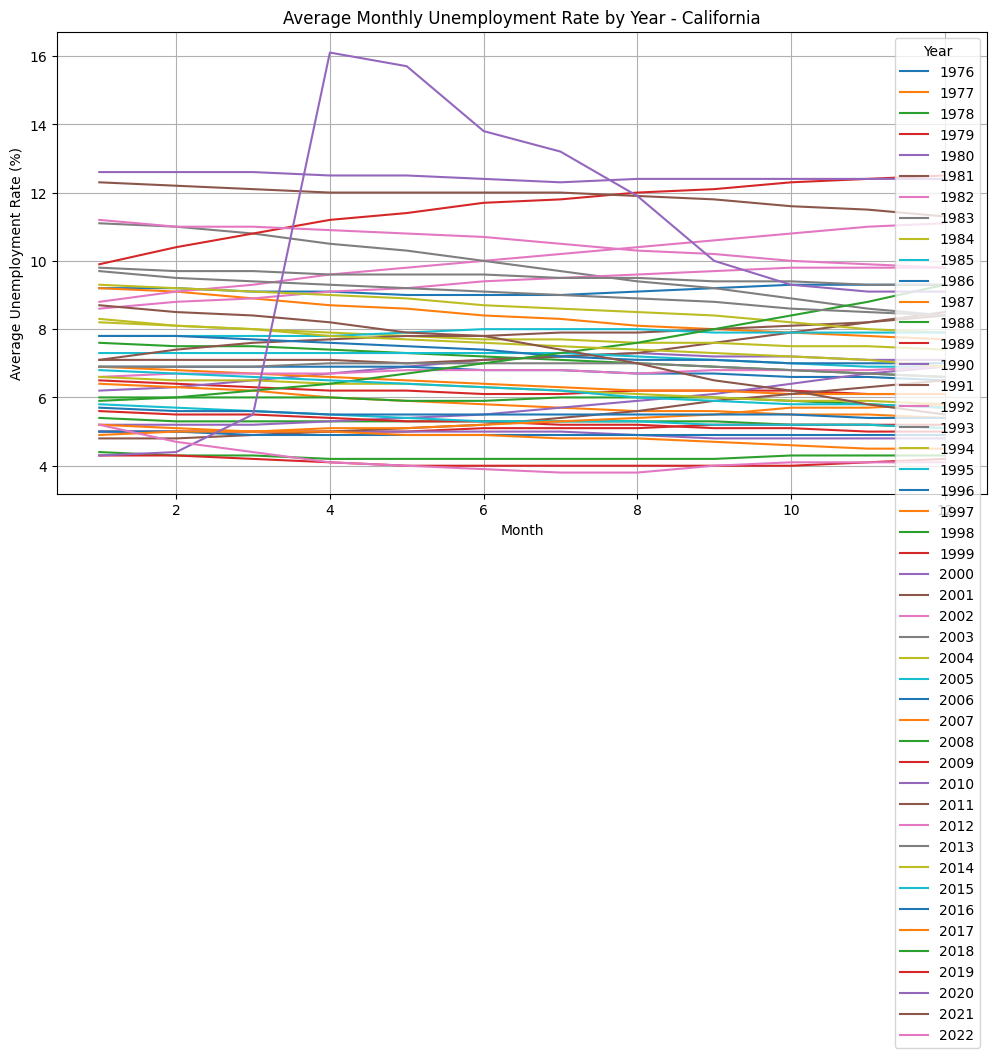

In [126]:
state_df['Year'] = state_df.index.year
state_df['Month'] = state_df.index.month

table = pd.pivot_table(state_df,
                       values=col,
                       index='Month',
                       columns='Year',
                       aggfunc='mean')

# --- 4️⃣ Gráfico tipo línea del pivot ---
fig, ax = plt.subplots(figsize=(12, 6))
table.plot(ax=ax, kind='line', legend=True)
ax.set_xlabel('Month')
ax.set_ylabel('Average Unemployment Rate (%)')
ax.set_title(f'Average Monthly Unemployment Rate by Year - {state}')
plt.grid(True)
plt.show()

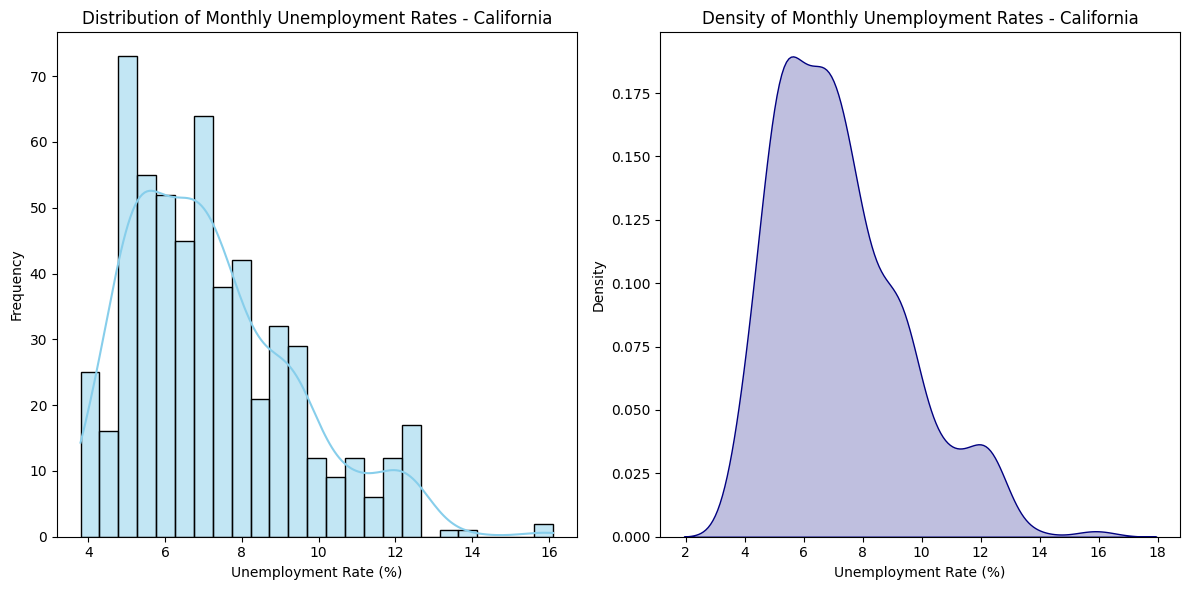

In [127]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.histplot(state_df[col], bins=25, kde=True, color='skyblue')
plt.title(f'Distribution of Monthly Unemployment Rates - {state}')
plt.xlabel('Unemployment Rate (%)')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.kdeplot(state_df[col], fill=True, color='navy')
plt.title(f'Density of Monthly Unemployment Rates - {state}')
plt.xlabel('Unemployment Rate (%)')

plt.tight_layout()
plt.show()

## 16 de octubre

In [128]:
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import seasonal_decompose


In [129]:
np.random.seed(42)
plt.rcParams['figure.figsize'] = (10, 4)


In [130]:
def plot_series(s, title):
    s.plot()
    plt.title(title)
    plt.xlabel("Time")
    plt.ylabel("Value")
    plt.grid(True)
    plt.show()

def adf_test(x):
    res = adfuller(x, autolag="AIC")
    keys = ['test_stat', 'pvalue', 'lags', 'nobs', 'crit_values', 'icbest']
    return dict(zip(keys, [res[0], res[1], res[2], res[3], res[4], res[5]]))

def kpss_test(x, regression="c", nlags="auto"):
    stat, pval, lags, crit = kpss(x, regression=regression, nlags=nlags) #la diferencia con la anterior función, es cómo lo regresa
    keys = ['test_stat', 'pvalue', 'lags', 'crit_values']
    return {"test_stat": stat, 
            "pvalue": pval, 
            "lags": lags, 
            "crit_values": crit, 
            "regression": regression}


def print_test(x, name="Series"):
    print(f"Test {name}")
    a = adf_test(x)
    print(f"ADF Statistic: {a['test_stat']:.3f} p={a['pvalue']}")

    try:
        k = kpss_test(x, regression="c")
        print(f"KPSS: stat={k['test_stst']:.3f} p={k['pvalue']}")
    except: 
        print("KPSS test failed")

def rolling_mean_var(s, window=24, title="Rolling Mean & Var"): #window es qué tantos valores toma en cuanta para caluclar el valor
    rolling_mean = s.rolling(window).mean()
    rolling_var = s.rolling(window).var()
    fig, ax = plt.subplots(2, 1, figsize=(10,6))
    ax[0].plot(s, label="Original")
    ax[0].plot(rolling_mean, label="Rolling Mean")
    ax[0].legend()
    ax[0].set_title(title + " - mean")
    ax[1].plot(rolling_var, label="Rolling var")
    ax[1].legend()
    ax[1].set_title(title + " - mean")
    plt.show()

In [131]:
n = 240 # months
t = np.arange(n)

#Stationary: white noise
white_noise = pd.Series(np.random.normal(0, 1, n))

# Non stationary
trend = 0.02 * t
trended = pd.Series(trend + np.random.normal(0, 1, n))

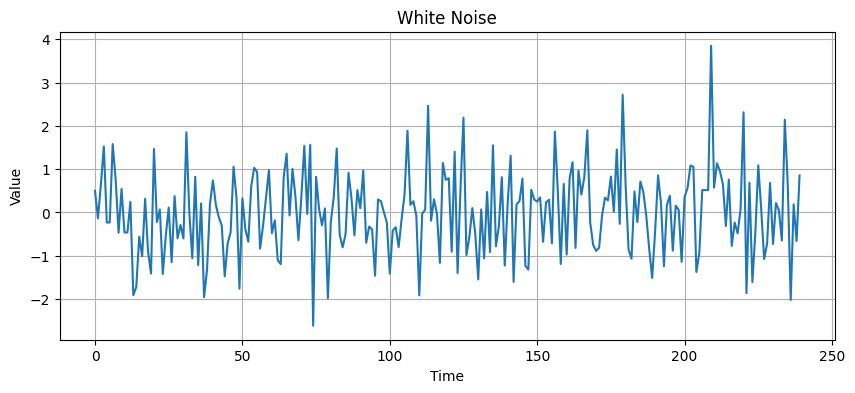

Test White Noise
ADF Statistic: -16.112 p=5.006520467194107e-29
KPSS test failed


C:\Users\kakop\AppData\Local\Temp\ipykernel_19796\2555747184.py:15: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, pval, lags, crit = kpss(x, regression=regression, nlags=nlags) #la diferencia con la anterior función, es cómo lo regresa


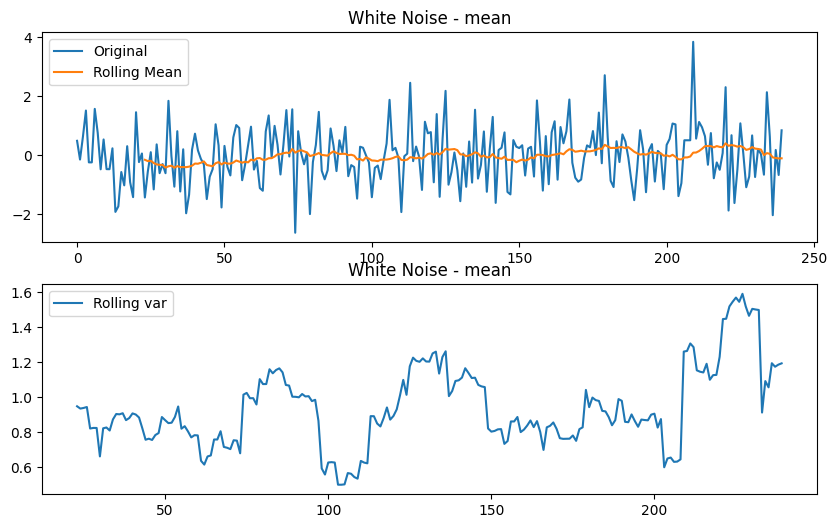

In [132]:
plot_series(white_noise, "White Noise")
print_test(white_noise, "White Noise")
rolling_mean_var(white_noise, window = 24, title="White Noise")

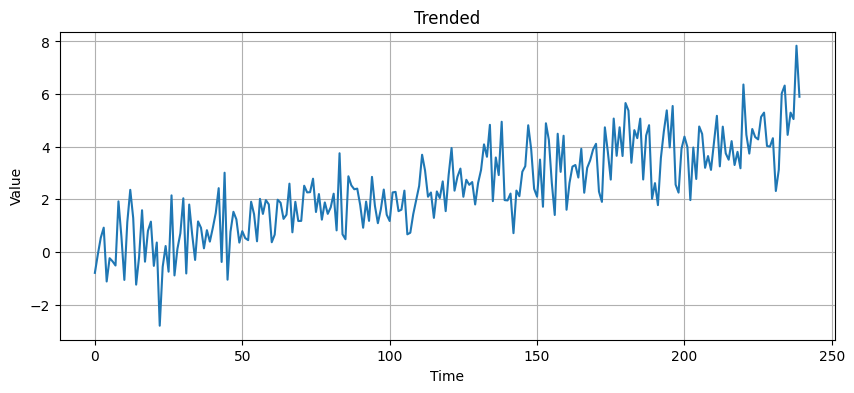

Test Trended
ADF Statistic: -0.057 p=0.9535945013089593
KPSS test failed


C:\Users\kakop\AppData\Local\Temp\ipykernel_19796\2555747184.py:15: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  stat, pval, lags, crit = kpss(x, regression=regression, nlags=nlags) #la diferencia con la anterior función, es cómo lo regresa


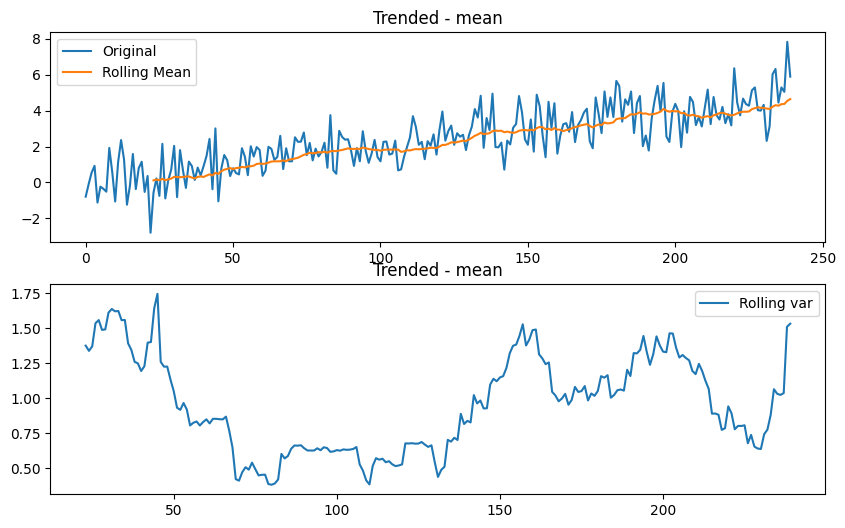

In [133]:
plot_series(trended, "Trended")
print_test(trended, "Trended")
rolling_mean_var(trended, window=24, title="Trended")

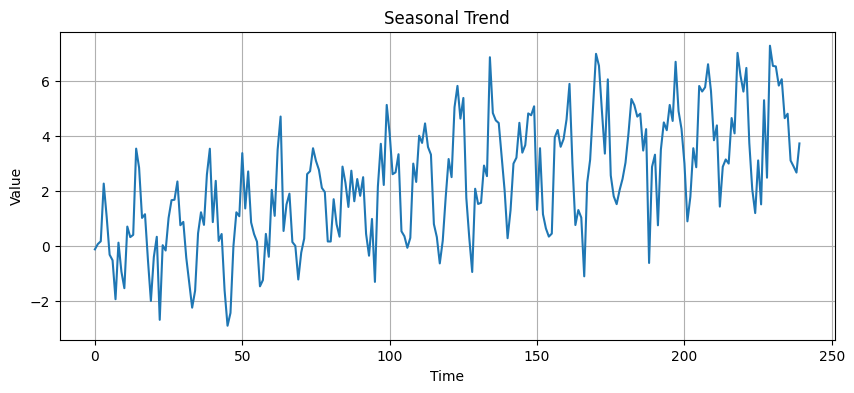

Test Seasonal Trend
ADF Statistic: -0.530 p=0.8860859361543615
KPSS test failed


C:\Users\kakop\AppData\Local\Temp\ipykernel_19796\2555747184.py:15: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  stat, pval, lags, crit = kpss(x, regression=regression, nlags=nlags) #la diferencia con la anterior función, es cómo lo regresa


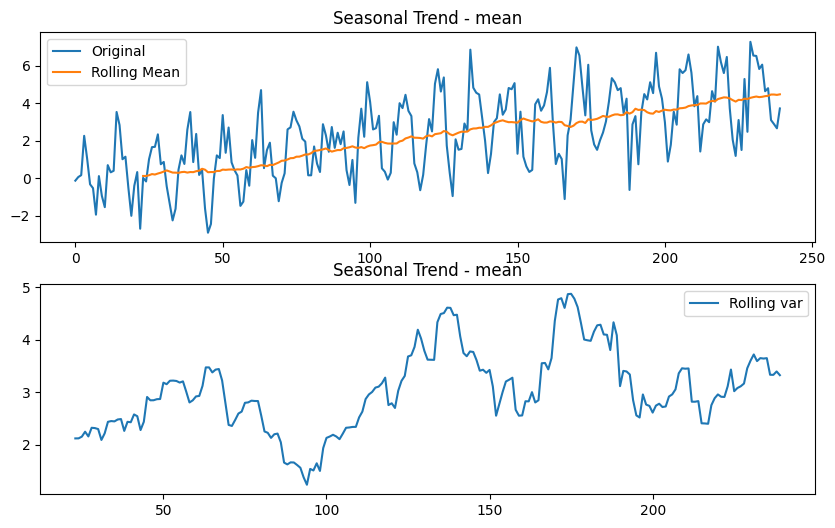

In [134]:
# -- Seasonal + trend

# Solmanete con seasonal
seasonal = 2 * np.sin(2 * np.pi*t/12)
trend = 0.02 * t
season_trend = pd.Series(trend + seasonal + np.random.normal(0, 1, n))
plot_series(season_trend, "Seasonal Trend")
print_test(season_trend, "Seasonal Trend")
rolling_mean_var(season_trend, window=24, title="Seasonal Trend")

---

In [135]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
df = pd.read_csv(url, parse_dates=['Month'], index_col='Month')
df.head(10)

,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
1949-06-01,135
1949-07-01,148
1949-08-01,148
1949-09-01,136


In [136]:
df.rename(columns={'Passengers':'y'}, inplace=True)
df.head()

,y
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


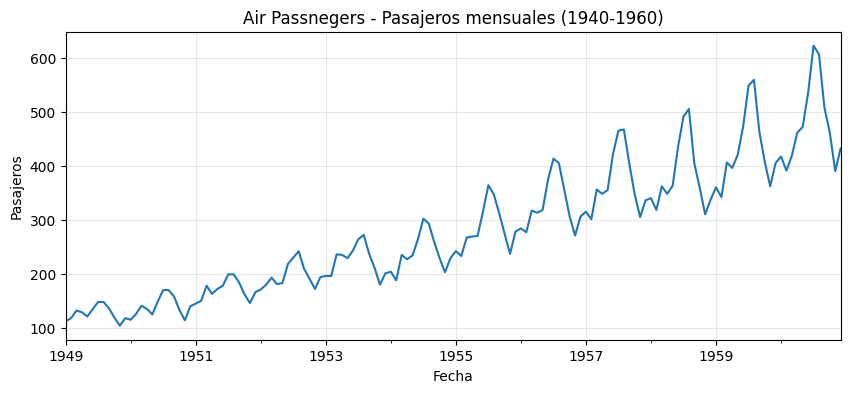

In [137]:
ax = df['y'].plot()
ax.set_title("Air Passnegers - Pasajeros mensuales (1940-1960)")
ax.set_xlabel("Fecha")
ax.set_ylabel("Pasajeros")
ax.grid(True, alpha=0.3)
plt.show()

In [138]:
from statsmodels.tsa.seasonal import seasonal_decompose

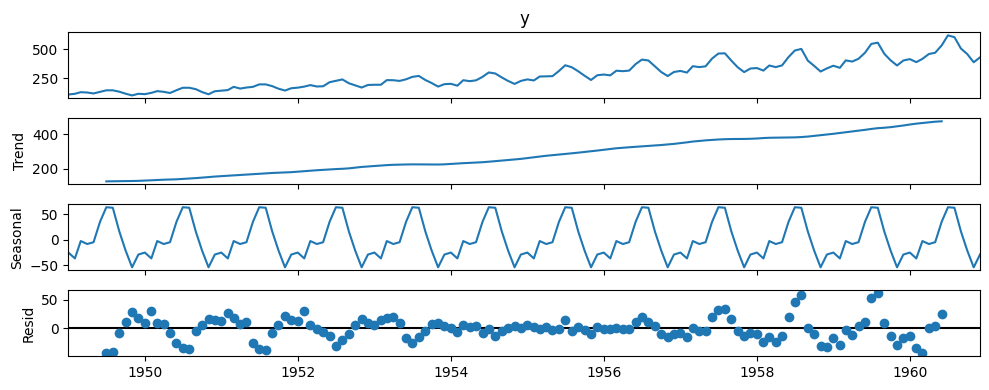

In [139]:
decomp = seasonal_decompose(df['y'], model="additive", period=12)
decomp.plot()
plt.show()


## 23 de Octubre 

In [140]:
from statsmodels.tsa.ar_model import AutoReg


#Fit an AR(1) model
model= AutoReg(df['y'], lags=1)
model_fit= model.fit()

#print the model summary
print(model_fit.summary())

                            AutoReg Model Results                             
Dep. Variable:                      y   No. Observations:                  144
Model:                     AutoReg(1)   Log Likelihood                -704.106
Method:               Conditional MLE   S.D. of innovations             33.277
Date:                Sat, 22 Nov 2025   AIC                           1414.212
Time:                        19:25:14   BIC                           1423.100
Sample:                    02-01-1949   HQIC                          1417.823
                         - 12-01-1960                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         13.7055      7.084      1.935      0.053      -0.178      27.589
y.L1           0.9589      0.023     41.106      0.000       0.913       1.005
                                    Roots           

c:\Users\kakop\miniconda3\envs\AmbienteDario\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


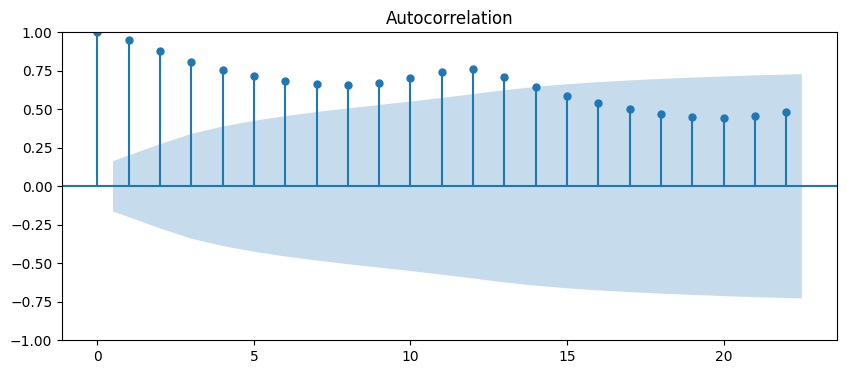

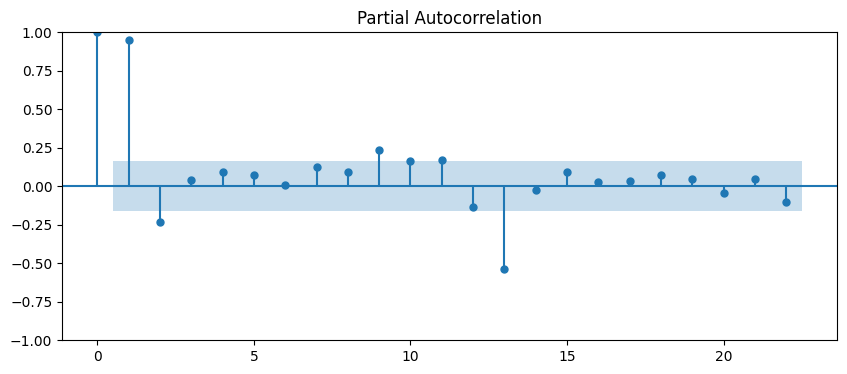

In [141]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Plot ACF and PACF
plot_acf(df['y'])
plt.show()
plot_pacf(df['y'])
plt.show()

In [142]:
from statsmodels.tsa.arima.model import ARIMA
# Fit en MA(1) model
model = ARIMA(df['y'], order=(0,0,1))
model_fit = model.fit()

#print the model summary
print(model_fit.summary())

c:\Users\kakop\miniconda3\envs\AmbienteDario\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\kakop\miniconda3\envs\AmbienteDario\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\kakop\miniconda3\envs\AmbienteDario\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\kakop\miniconda3\envs\AmbienteDario\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  144
Model:                 ARIMA(0, 0, 1)   Log Likelihood                -806.431
Date:                Sat, 22 Nov 2025   AIC                           1618.863
Time:                        19:25:15   BIC                           1627.772
Sample:                    01-01-1949   HQIC                          1622.483
                         - 12-01-1960                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        280.6521     11.648     24.094      0.000     257.822     303.482
ma.L1          0.9642      0.030     32.205      0.000       0.906       1.023
sigma2      4205.0752    586.678      7.168      0.0

In [143]:
# Fit an ARIMA(1,1,1)
model = ARIMA(df['y'], order=(12,1,1))
model_fit = model.fit()

#print the model summary
print(model_fit.summary())

c:\Users\kakop\miniconda3\envs\AmbienteDario\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\kakop\miniconda3\envs\AmbienteDario\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\kakop\miniconda3\envs\AmbienteDario\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\kakop\miniconda3\envs\AmbienteDario\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'


                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  144
Model:                ARIMA(12, 1, 1)   Log Likelihood                -558.711
Date:                Sat, 22 Nov 2025   AIC                           1145.422
Time:                        19:25:17   BIC                           1186.902
Sample:                    01-01-1949   HQIC                          1162.277
                         - 12-01-1960                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1019      0.067      1.523      0.128      -0.029       0.233
ar.L2         -0.0920      0.060     -1.526      0.127      -0.210       0.026
ar.L3          0.0100      0.054      0.184      0.8

c:\Users\kakop\miniconda3\envs\AmbienteDario\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


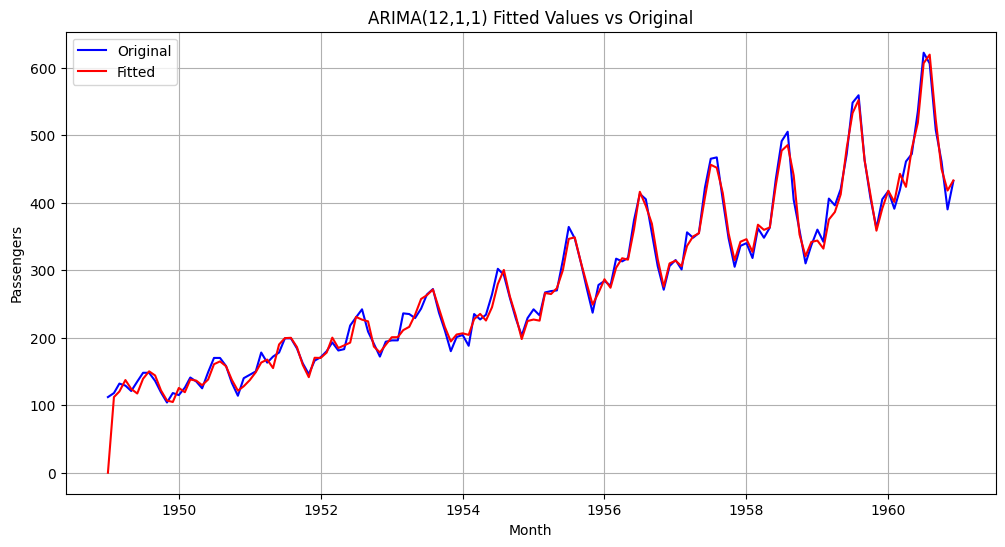

In [144]:
# Plot the fitted values 
plt.figure(figsize=(12, 6))
plt.plot(df['y'], label='Original', color='blue')
plt.plot(model_fit.fittedvalues, label='Fitted', color='red')
plt.title('ARIMA(12,1,1) Fitted Values vs Original')
plt.xlabel('Month')
plt.ylabel('Passengers')
plt.legend()
plt.grid(True)
plt.show()